In [ ]:
import os
import jieba # 导入中文分词库 jieba
from collections import Counter # Counter 用来高效统计元素出现次数
import pandas as pd
from tqdm import tqdm

/Users/zhangyuxin/miniconda3/envs/cs224n/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# 加载文本函数：遍历文件夹读取新闻
# base_dir:THUCNews 数据集的根目录
def load_texts(base_dir, limit_per_class=1000): 
    texts = []
    labels = []
    for category in os.listdir(base_dir):
        cat_dir = os.path.join(base_dir, category) # 把根目录和类别名拼成完整路径（兼容 Windows/Linux 的路径分隔）
        if not os.path.isdir(cat_dir):
            continue
        files = os.listdir(cat_dir)[:limit_per_class]  # 可选：限制每类样本数量
        for fname in files:
            with open(os.path.join(cat_dir, fname), 'r', encoding='utf-8') as f:
                texts.append(f.read())
                labels.append(category)
    return texts, labels

# 使用函数加载数据并查看
base_dir = "THUCNews"
texts, labels = load_texts(base_dir)
print(f"共加载 {len(texts)} 篇新闻")


共加载 14000 篇新闻


In [8]:
# 分词：把所有文本切成词
# 定义分词函数，输入是一个文本字符串列表 texts
def segment_texts(texts):
    seg_list = []
    for text in tqdm(texts):
        seg_list.extend(jieba.cut(text))
    return seg_list 
#seg_list 最终是一个长的一维列表，包含整个语料按顺序的所有词。

all_words = segment_texts(texts)


100%|██████████| 14000/14000 [00:13<00:00, 1024.27it/s]


In [9]:
# 去停用词（stopwords）与清理
def remove_stopwords(words, stopwords_path="stopwords.txt"):
    stopwords = set(open(stopwords_path, encoding='utf-8').read().splitlines())
    return [w for w in words if w not in stopwords and len(w.strip()) > 1]

clean_words = remove_stopwords(all_words)


In [10]:
# 词频统计
word_freq = Counter(clean_words)
df_freq = pd.DataFrame(word_freq.most_common(50), columns=["word", "count"])
print(df_freq.head())


  word  count
0   一个  14544
1   基金  12273
2   市场  11531
3   公司  10944
4   没有  10852


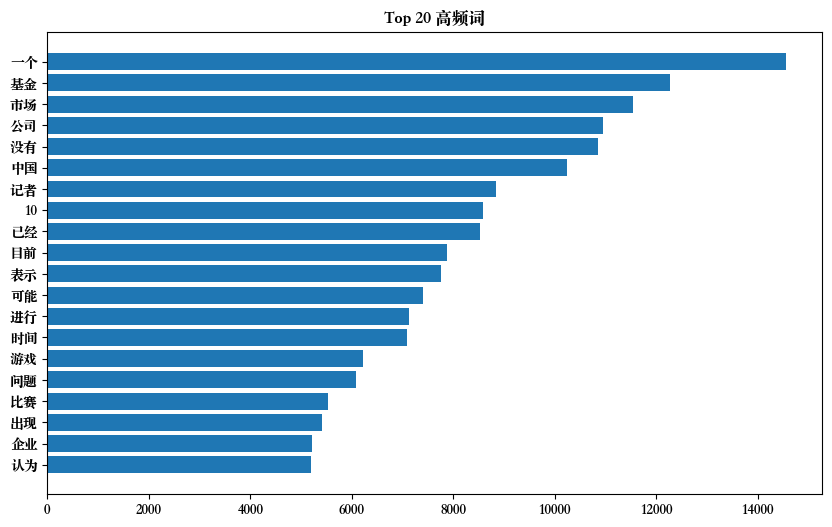

In [11]:
# 词频可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df_freq["word"][:20][::-1], df_freq["count"][:20][::-1])
plt.title("Top 20 高频词")
plt.show()


In [12]:
df_freq.to_csv("thucnews_word_frequency.csv", index=False)
